In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

In [47]:
df = pd.read_csv('processed_stock_data.csv')
df

,Date,Open,High,Low,Close,Volume,50-day MA,200-day MA,Close_diff,lag_1,lag_7,rolling_mean_7,rolling_std_7
0,2012-01-03,58.485714,58.928570,58.428570,58.747143,75555200,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2012-01-04,58.571430,59.240002,58.468571,59.062859,65005500,NaN,NaN,0.315716,58.747143,NaN,NaN,NaN
2,2012-01-05,59.278572,59.792858,58.952858,59.718571,67817400,NaN,NaN,0.655712,59.062859,NaN,NaN,NaN
3,2012-01-06,59.967144,60.392857,59.888573,60.342857,79573200,NaN,NaN,0.624286,59.718571,NaN,NaN,NaN
4,2012-01-09,60.785713,61.107143,60.192856,60.247143,98506100,NaN,NaN,-0.095714,60.342857,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2006,2019-12-23,280.529999,284.250000,280.369995,283.809289,24643000,259.670586,216.528297,4.369287,279.440002,271.459991,279.775608,2.524879
2007,2019-12-24,284.150718,284.890015,280.977848,283.809289,12119700,260.629372,217.042793,0.000000,283.809289,275.149994,281.012650,1.932721
2008,2019-12-26,284.150718,288.448204,280.977848,283.809289,23280300,261.599157,217.553289,0.000000,283.809289,279.859985,281.576836,2.108589
2009,2019-12-27,284.150718,288.448204,280.977848,283.809289,36566500,262.587943,218.053686,0.000000,283.809289,280.410004,282.062448,2.185120


In [48]:
# Convert 'Date' column to datetime format
df['Date'] = pd.to_datetime(df['Date'])
df.head()

,Date,Open,High,Low,Close,Volume,50-day MA,200-day MA,Close_diff,lag_1,lag_7,rolling_mean_7,rolling_std_7
0,2012-01-03,58.485714,58.928570,58.428570,58.747143,75555200,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2012-01-04,58.571430,59.240002,58.468571,59.062859,65005500,NaN,NaN,0.315716,58.747143,NaN,NaN,NaN
2,2012-01-05,59.278572,59.792858,58.952858,59.718571,67817400,NaN,NaN,0.655712,59.062859,NaN,NaN,NaN
3,2012-01-06,59.967144,60.392857,59.888573,60.342857,79573200,NaN,NaN,0.624286,59.718571,NaN,NaN,NaN
4,2012-01-09,60.785713,61.107143,60.192856,60.247143,98506100,NaN,NaN,-0.095714,60.342857,NaN,NaN,NaN


In [49]:
df.dtypes

Date              datetime64[ns]
Open                     float64
High                     float64
Low                      float64
Close                    float64
Volume                     int64
50-day MA                float64
200-day MA               float64
Close_diff               float64
lag_1                    float64
lag_7                    float64
rolling_mean_7           float64
rolling_std_7            float64
dtype: object

In [50]:
df = df[["Date", 'Close']]

In [51]:
# Set 'Date' as the index
df.set_index('Date', inplace=True)

In [52]:
df

,Close
Date,
2012-01-03,58.747143
2012-01-04,59.062859
2012-01-05,59.718571
2012-01-06,60.342857
2012-01-09,60.247143
...,...
2019-12-23,283.809289
2019-12-24,283.809289
2019-12-26,283.809289


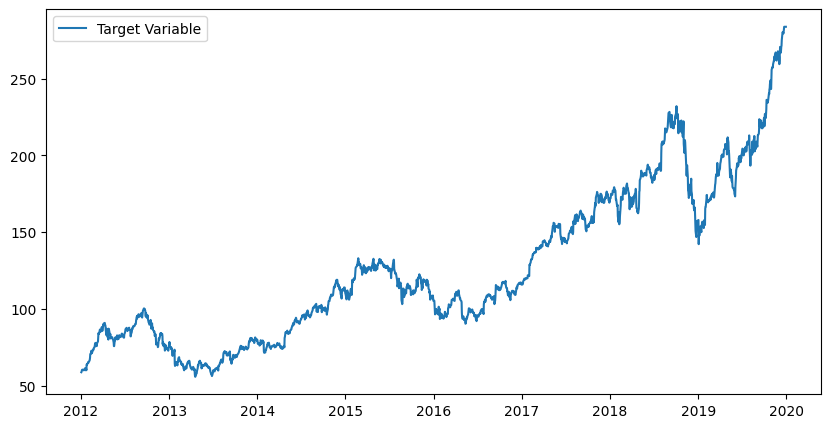

In [53]:
# Visualize the data
plt.figure(figsize=(10,5))
plt.plot(df, label="Target Variable")
plt.legend()
plt.show()

In [54]:
#3. Feature Engineering for Time Series

# Creating lag features
def create_features(df, target, lags=5):
    data = df.copy()
    
    # Creating lag features (previous values as features)
    for lag in range(1, lags+1):
        data[f'lag_{lag}'] = data[target].shift(lag)
    
    # Creating rolling window features
    data['rolling_mean_3'] = data[target].rolling(window=3).mean()
    data['rolling_std_3'] = data[target].rolling(window=3).std()
    
    # Creating time-based features
    data['month'] = data.index.month
    data['day'] = data.index.day
    data['weekday'] = data.index.weekday

    return data

In [55]:

# Apply the function
df = create_features(df, target="Close")

In [56]:
df

,Close,lag_1,lag_2,lag_3,lag_4,lag_5,rolling_mean_3,rolling_std_3,month,day,weekday
Date,,,,,,,,,,,
2012-01-03,58.747143,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,3,1
2012-01-04,59.062859,58.747143,NaN,NaN,NaN,NaN,NaN,NaN,1,4,2
2012-01-05,59.718571,59.062859,58.747143,NaN,NaN,NaN,59.176191,0.495531,1,5,3
2012-01-06,60.342857,59.718571,59.062859,58.747143,NaN,NaN,59.708096,0.640063,1,6,4
2012-01-09,60.247143,60.342857,59.718571,59.062859,58.747143,NaN,60.102857,0.336225,1,9,0
...,...,...,...,...,...,...,...,...,...,...,...
2019-12-23,283.809289,279.440002,280.019989,279.739990,280.410004,279.859985,281.089760,2.372968,12,23,0
2019-12-24,283.809289,283.809289,279.440002,280.019989,279.739990,280.410004,282.352860,2.522609,12,24,1
2019-12-26,283.809289,283.809289,283.809289,279.440002,280.019989,279.739990,283.809289,0.000000,12,26,3


In [57]:
# Drop NaN values (due to lag features)
df.dropna(inplace=True)

In [58]:
# View the transformed data
print(df.head())

                Close      lag_1      lag_2      lag_3      lag_4      lag_5  \
Date                                                                           
2012-01-10  60.462856  60.247143  60.342857  59.718571  59.062859  58.747143   
2012-01-11  60.364285  60.462856  60.247143  60.342857  59.718571  59.062859   
2012-01-12  60.198570  60.364285  60.462856  60.247143  60.342857  59.718571   
2012-01-13  59.972858  60.198570  60.364285  60.462856  60.247143  60.342857   
2012-01-17  60.671429  59.972858  60.198570  60.364285  60.462856  60.247143   

            rolling_mean_3  rolling_std_3  month  day  weekday  
Date                                                            
2012-01-10       60.350952       0.108084      1   10        1  
2012-01-11       60.358095       0.107990      1   11        2  
2012-01-12       60.341904       0.133557      1   12        3  
2012-01-13       60.178571       0.196478      1   13        4  
2012-01-17       60.280952       0.356498      1 

In [59]:
#Split Data into Training and Testing Sets
# Define features and target
X = df.drop(columns=["Close"])  # Features
y = df["Close"]  # Target

In [60]:
train_size = 1981
Train = df.head(train_size)
Test = df.tail(len(df) - train_size)  # Automatically gets the remaining rows

# Split features (X) and target (y) into train/test sets
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [61]:
#Scale the Data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [62]:
#Train the XGBoost Model
# Define the model
model = xgb.XGBRegressor(
    objective="reg:squarederror",
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)


In [63]:
# Train the model
model.fit(X_train_scaled, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=5, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

**Make Predictions**

In [64]:
# Predict on test data
y_pred = model.predict(X_test_scaled)

In [65]:
# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

In [66]:
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

Mean Absolute Error (MAE): 9.99
Root Mean Squared Error (RMSE): 12.51
